In [82]:
import sys
print(sys.executable)
    

/home/daniel.lien/dev/homework/Chronic_Disease_Indicators_Data_Visualization/.venv/bin/python


In [83]:
path = '/home/daniel.lien/dev/homework/data/U.S._Chronic_Disease_Indicators_20250204.csv'

In [84]:
import pandas as pd 

In [85]:
df = pd.read_csv(path)
df.head()

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,...,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
0,2019,2019,AR,Arkansas,BRFSS,Diabetes,Diabetes among adults,NaN,%,Crude Prevalence,...,DIA,DIA01,NaN,CRDPREV,SEX,SEXM,NaN,NaN,NaN,NaN
1,2019,2019,ID,Idaho,BRFSS,Diabetes,Diabetes among adults,NaN,%,Crude Prevalence,...,DIA,DIA01,NaN,CRDPREV,SEX,SEXM,NaN,NaN,NaN,NaN
2,2019,2019,IN,Indiana,YRBSS,Sleep,Short sleep duration among high school students,NaN,%,Crude Prevalence,...,SLEP,SLP02,NaN,CRDPREV,GRADE,GRD12,NaN,NaN,NaN,NaN
3,2019,2019,IA,Iowa,NVSS,Asthma,"Asthma mortality among all people, underlying ...",NaN,Number,Number,...,AST,AST01,NaN,NMBR,OVERALL,OVR,NaN,NaN,NaN,NaN
4,2019,2019,IA,Iowa,BRFSS,Asthma,Current asthma among adults,NaN,%,Crude Prevalence,...,AST,AST02,NaN,CRDPREV,AGE,AGE1844,NaN,NaN,NaN,NaN


In [86]:
df.columns

Index(['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc', 'DataSource',
       'Topic', 'Question', 'Response', 'DataValueUnit', 'DataValueType',
       'DataValue', 'DataValueAlt', 'DataValueFootnoteSymbol',
       'DataValueFootnote', 'LowConfidenceLimit', 'HighConfidenceLimit',
       'StratificationCategory1', 'Stratification1', 'StratificationCategory2',
       'Stratification2', 'StratificationCategory3', 'Stratification3',
       'Geolocation', 'LocationID', 'TopicID', 'QuestionID', 'ResponseID',
       'DataValueTypeID', 'StratificationCategoryID1', 'StratificationID1',
       'StratificationCategoryID2', 'StratificationID2',
       'StratificationCategoryID3', 'StratificationID3'],
      dtype='object')

In [97]:
print(df["QuestionID"].unique())
print(df["ResponseID"].unique())


['DIA01' 'SLP02' 'AST01' 'AST02' 'DIA03' 'HEA04' 'MEN02' 'ALC01' 'HEA06'
 'ART03' 'TOB04' 'ART01' 'DIS01' 'ALC06' 'ART05' 'IMM01' 'ALC05' 'ALC09'
 'HEA05' 'ORH01' 'SLP03' 'HEA01' 'ORH03' 'HEA03' 'NPW14' 'MEN05' 'CAN07'
 'CAN08' 'CAN01' 'CAN03' 'CAN02' 'CAN05' 'CAN04' 'CVD09' 'NPW07' 'COPD03'
 'ART06' 'ART07' 'CVD07' 'ORH04' 'ORH05' 'COPD05' 'COPD06' 'NPW06' 'CHC02'
 'SDH12' 'TOB06' 'IMM04' 'SLP01' 'COPD01' 'MEN04' 'CVD02' 'CVD06' 'CVD04'
 'NPW03' 'CHC03' 'HEA02' 'ALC04' 'COPD02' 'IMM03' 'COPD04' 'CVD01' 'SDH09'
 'TOB02' 'TOB03' 'ART04' 'SDH08' 'CHC01' 'NPW09' 'NPW04' 'ORH07' 'ALC07'
 'TOB01' 'ART02' 'SDH10' 'NPW13' 'MAT01' 'IMM02' 'CVD08' 'MEN03' 'NPW05'
 'CVD03' 'CHC04' 'DIA04' 'DIA02' 'SDH01' 'NPW02' 'SDH03' 'NPW01' 'CKD01'
 'SDH11' 'TOB05' 'NPW08' 'ALC08' 'SDH02' 'NPW10' 'TOB07' 'NPW11' 'SDH04'
 'CAN06' 'CAN10' 'CAN09' 'ORH06' 'NPW12' 'ORH02' 'MEN01' 'SDH05' 'SDH07'
 'SDH06']
[nan]


In [98]:
print(df["StratificationCategory1"].unique()) 
print(df["StratificationCategory2"].unique()) 
print(df["StratificationCategory3"].unique()) 
print(df["Stratification1"].unique())
print(df["Stratification2"].unique())
print(df["Stratification3"].unique())


['Sex' 'Grade' 'Overall' 'Age' 'Race/Ethnicity']
[nan]
[nan]
['Male' 'Grade 12' 'Overall' 'Age 18-44' 'Age 0-44' 'Female'
 'Multiracial, non-Hispanic' 'Age 45-64' 'Hispanic' 'Age >=65' 'Grade 11'
 'White, non-Hispanic' 'Black, non-Hispanic'
 'American Indian or Alaska Native, non-Hispanic'
 'Asian or Pacific Islander, non-Hispanic'
 'Hawaiian or Pacific Islander, non-Hispanic' 'Asian, non-Hispanic'
 'Age 4 m - 5 y' 'Age 6-14' 'Grade 9' 'Age 1-5' 'Age 12-17' 'Age 6-9'
 'Age 10-13' 'Age 6-11' 'Grade 10']
[nan]
[nan]


In [ ]:
# Create and understand Strata
def generate_summary(row):
    # Extract relevant data for the sentence
    topic = row["Topic"]
    question = row["Question"]
    
    stratification = []
    
    # Add the stratification information (if available)
    if pd.notna(row["StratificationCategory1"]):
        stratification.append(f"by {row['StratificationCategory1']} ({row['Stratification1']})")
    if pd.notna(row["StratificationCategory2"]):
        stratification.append(f"by {row['StratificationCategory2']} ({row['Stratification2']})")
    if pd.notna(row["StratificationCategory3"]):
        stratification.append(f"by {row['StratificationCategory3']} ({row['Stratification3']})")
    
    # Combine the stratifications into one sentence part
    stratification_info = ", ".join(stratification) if stratification else "with no stratification"
    
    # Build the summary sentence
    summary = f"This survey recorded the question '{question}' for the disease '{topic}', stratified {stratification_info}."
    
    return summary

# Apply the function to each row in the dataframe
df['survey_summary'] = df.apply(generate_summary, axis=1)

# Now you can view the summary for any row
print(df['survey_summary'].head())


# Entire Chronic Disease Indicators Dataset 

In [ ]:
df.describe().T
df.info()
df.shape
df.columns

In [ ]:
df.isnull().sum()
#The entire response column in null
#Stratification Category 2, Stratification2, StratificationCategory3, Stratification3 are Null
#ID2 and ID3 are null

In [12]:
#Print Unique Topics and Questions
print(df["Topic"].unique())  # Unique health topics
print(df["Question"].unique())  # Specific health indicators


['Diabetes' 'Sleep' 'Asthma' 'Health Status' 'Mental Health' 'Alcohol'
 'Arthritis' 'Tobacco' 'Disability' 'Immunization' 'Oral Health'
 'Nutrition, Physical Activity, and Weight Status' 'Cancer'
 'Cardiovascular Disease' 'Chronic Obstructive Pulmonary Disease'
 'Cognitive Health and Caregiving' 'Social Determinants of Health'
 'Maternal Health' 'Chronic Kidney Disease']
['Diabetes among adults' 'Short sleep duration among high school students'
 'Asthma mortality among all people, underlying cause'
 'Current asthma among adults'
 'Diabetes mortality among all people, underlying or contributing cause'
 'Recent activity limitation among adults' 'Depression among adults'
 'Alcohol use among high school students' 'Life expectancy at birth'
 'Severe joint pain among adults with arthritis'
 'Current cigarette smoking among adults' 'Arthritis among adults'
 'Adults with any disability' 'Binge drinking prevalence among adults'
 'Physical inactivity among adults with arthritis'
 'Influenza vacc

In [13]:
df["DataValue"].describe()


count    2.091960e+05
mean     6.943569e+02
std      1.620341e+04
min      0.000000e+00
25%      1.240000e+01
50%      2.700000e+01
75%      5.780000e+01
max      2.925456e+06
Name: DataValue, dtype: float64

In [14]:
#Data Cleaning and Preprocessing
df.dropna(subset=["DataValue"], inplace=True)  # Remove rows where DataValue is missing
df.fillna("Unknown", inplace=True)  # Fill missing categorical data with 'Unknown'
df["DataValue"] = pd.to_numeric(df["DataValue"], errors="coerce")


In [31]:
#Focus on one health topic
copd_df = df[df["Topic"] == "Chronic Obstructive Pulmonary Disease"]
copd_df.head()

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,...,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
14201,2019,2019,AZ,Arizona,CMS Part A Claims Data,Chronic Obstructive Pulmonary Disease,Hospitalization for chronic obstructive pulmon...,Unknown,"cases per 1,000",Crude Rate,...,COPD,COPD03,Unknown,CRDRATE,RACE,HIS,Unknown,Unknown,Unknown,Unknown
14217,2019,2019,AZ,Arizona,NVSS,Chronic Obstructive Pulmonary Disease,Chronic obstructive pulmonary disease mortalit...,Unknown,Number,Number,...,COPD,COPD06,Unknown,NMBR,RACE,AIAN,Unknown,Unknown,Unknown,Unknown
14222,2019,2019,CA,California,NVSS,Chronic Obstructive Pulmonary Disease,Chronic obstructive pulmonary disease mortalit...,Unknown,Number,Number,...,COPD,COPD06,Unknown,NMBR,RACE,HAPI,Unknown,Unknown,Unknown,Unknown
14243,2019,2019,AR,Arkansas,BRFSS,Chronic Obstructive Pulmonary Disease,Chronic obstructive pulmonary disease among ad...,Unknown,%,Crude Prevalence,...,COPD,COPD01,Unknown,CRDPREV,AGE,AGE1844,Unknown,Unknown,Unknown,Unknown
14273,2019,2019,CA,California,BRFSS,Chronic Obstructive Pulmonary Disease,Chronic obstructive pulmonary disease among ad...,Unknown,%,Crude Prevalence,...,COPD,COPD01,Unknown,CRDPREV,SEX,SEXM,Unknown,Unknown,Unknown,Unknown


In [32]:
copd_df.shape


(18337, 34)

In [33]:
#These are the unique questions related to COPD in the dataset
copd_df["Question"].unique()


array(['Hospitalization for chronic obstructive pulmonary disease as any diagnosis, Medicare-beneficiaries aged 65 years and older',
       'Chronic obstructive pulmonary disease mortality among adults aged 45 years and older, underlying or contributing cause',
       'Chronic obstructive pulmonary disease among adults',
       'Current smoking among adults with chronic obstructive pulmonary disease',
       'Hospitalization for chronic obstructive pulmonary disease as principal diagnosis, Medicare-beneficiaries aged 65 years and older',
       'Chronic obstructive pulmonary disease mortality among adults aged 45 years and older, underlying cause'],
      dtype=object)

In [34]:
#Check the values types that are reported 
copd_df["DataValueType"].unique()


array(['Crude Rate', 'Number', 'Crude Prevalence',
       'Age-adjusted Prevalence', 'Age-adjusted Rate'], dtype=object)

In [37]:
#Locations: there are 55 --> lets remove the ones that are not states
#remove Virgin Islands, Puerto Rico, Guam, District of Columbia, and United States
print(len(copd_df["LocationDesc"].unique()))
copd_df["LocationDesc"].unique()

55


array(['Arizona', 'California', 'Arkansas', 'Alabama', 'Alaska',
       'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Colorado',
       'Hawaii', 'District of Columbia', 'Guam', 'Louisiana', 'Iowa',
       'Kentucky', 'Kansas', 'Illinois', 'Indiana', 'Idaho', 'Maryland',
       'Maine', 'Nevada', 'Michigan', 'Massachusetts', 'Minnesota',
       'Montana', 'Missouri', 'Nebraska', 'Mississippi', 'New York',
       'North Carolina', 'New Jersey', 'New Hampshire', 'Ohio',
       'New Mexico', 'Oklahoma', 'North Dakota', 'United States',
       'Pennsylvania', 'South Carolina', 'Tennessee', 'Rhode Island',
       'South Dakota', 'Texas', 'Oregon', 'Puerto Rico', 'West Virginia',
       'Utah', 'Wyoming', 'Vermont', 'Virginia', 'Washington',
       'Wisconsin', 'Virgin Islands'], dtype=object)

In [38]:
#Time Coverage
copd_df["YearStart"].min(), copd_df["YearStart"].max()


(2019, 2022)

In [39]:
#Check Stratification Options
copd_df["StratificationCategory1"].unique()


array(['Race/Ethnicity', 'Age', 'Sex', 'Overall'], dtype=object)

In [43]:
copd_df.isnull().sum()


YearStart                    0
YearEnd                      0
LocationAbbr                 0
LocationDesc                 0
DataSource                   0
Topic                        0
Question                     0
Response                     0
DataValueUnit                0
DataValueType                0
DataValue                    0
DataValueAlt                 0
DataValueFootnoteSymbol      0
DataValueFootnote            0
LowConfidenceLimit           0
HighConfidenceLimit          0
StratificationCategory1      0
Stratification1              0
StratificationCategory2      0
Stratification2              0
StratificationCategory3      0
Stratification3              0
Geolocation                  0
LocationID                   0
TopicID                      0
QuestionID                   0
ResponseID                   0
DataValueTypeID              0
StratificationCategoryID1    0
StratificationID1            0
StratificationCategoryID2    0
StratificationID2            0
Stratifi

# Example Analysis

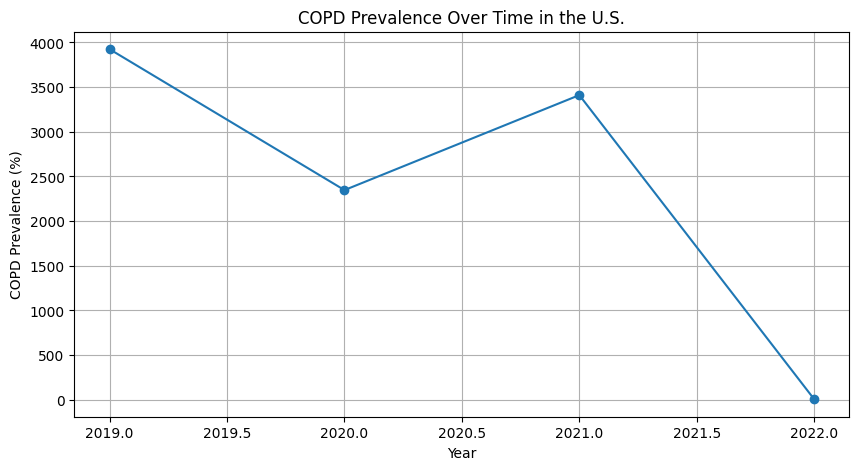

In [19]:
import matplotlib.pyplot as plt

# Aggregate obesity data by year
copd_trends = copd_df.groupby("YearStart")["DataValue"].mean()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(copd_trends.index, copd_trends.values, marker='o')
plt.xlabel("Year")
plt.ylabel("COPD Prevalence (%)")
plt.title("COPD Prevalence Over Time in the U.S.")
plt.grid()
plt.show()


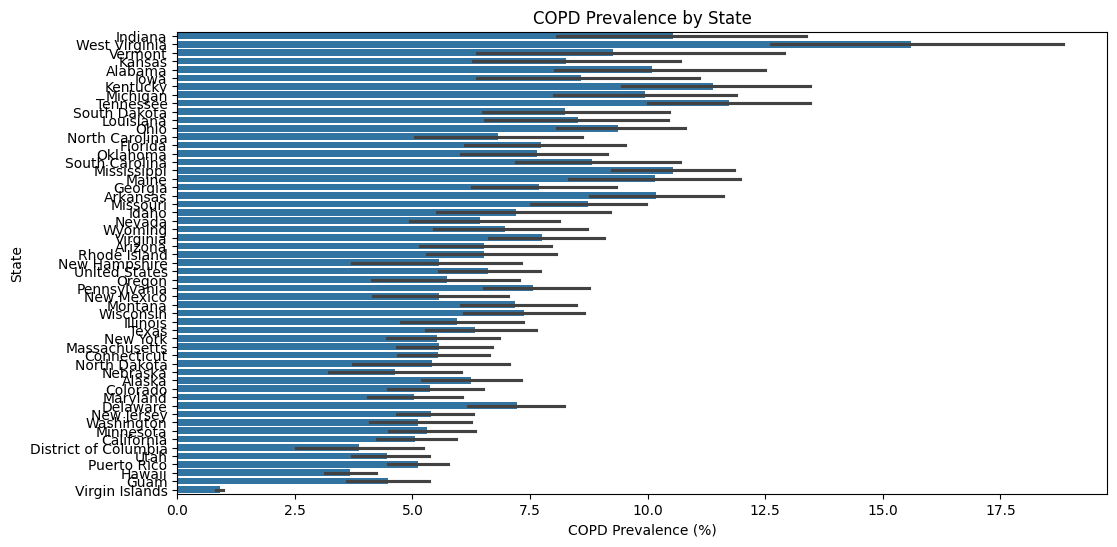

In [20]:
import seaborn as sns

# Get latest year data for obesity
latest_obesity = copd_df[copd_df["YearStart"] == copd_df["YearStart"].max()]

# Plot bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x="DataValue", y="LocationDesc", data=latest_obesity.sort_values("DataValue", ascending=False))
plt.xlabel("COPD Prevalence (%)")
plt.ylabel("State")
plt.title("COPD Prevalence by State")
plt.show()


In [26]:
#Correlation
df_subset = df[df["Topic"].isin(["Chronic Obstructive Pulmonary Disease", "Tobacco"])]
correlation_matrix = df_subset.pivot_table(index=["YearStart", "LocationDesc"], columns="Topic", values="DataValue").corr()
print(correlation_matrix)


Topic                                  Chronic Obstructive Pulmonary Disease  \
Topic                                                                          
Chronic Obstructive Pulmonary Disease                               1.000000   
Tobacco                                                            -0.039125   

Topic                                   Tobacco  
Topic                                            
Chronic Obstructive Pulmonary Disease -0.039125  
Tobacco                                1.000000  


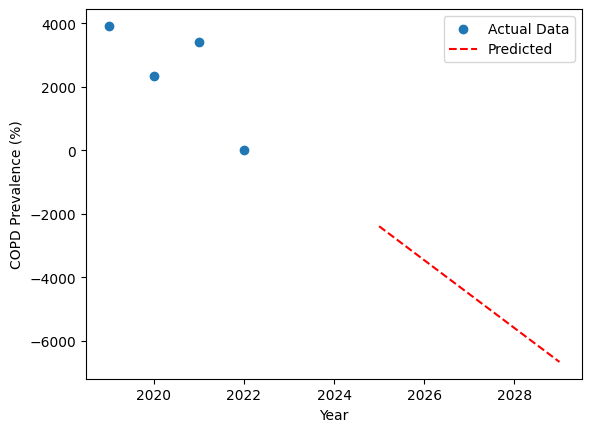

In [29]:
# Example Modeling
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data
X = copd_trends.index.values.reshape(-1, 1)
y = copd_trends.values

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict next 5 years
future_years = np.array(range(2025, 2030)).reshape(-1, 1)
future_preds = model.predict(future_years)

# Plot predictions
plt.scatter(X, y, label="Actual Data")
plt.plot(future_years, future_preds, color="red", linestyle="dashed", label="Predicted")
plt.xlabel("Year")
plt.ylabel("COPD Prevalence (%)")
plt.legend()
plt.show()


/home/daniel.lien/dev/homework/Chronic_Disease_Indicators_Data_Visualization/.venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


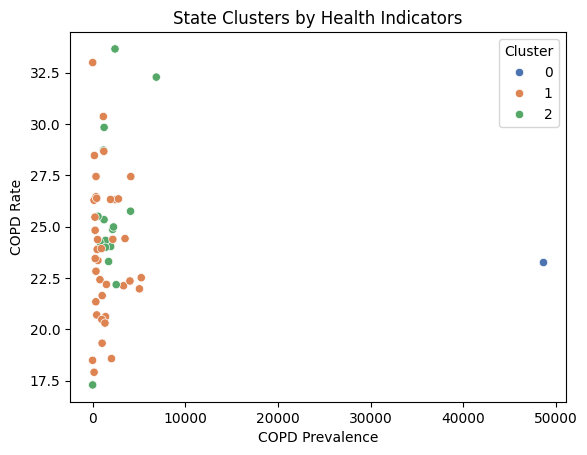

In [30]:
#Clustering states based on COPD and Tobacco Use
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select features
statewise_data = df.pivot_table(index="LocationDesc", columns="Topic", values="DataValue", aggfunc="mean").fillna(0)

# Normalize data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(statewise_data)

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels
statewise_data["Cluster"] = clusters

# Visualize clusters
sns.scatterplot(x=statewise_data["Chronic Obstructive Pulmonary Disease"], y=statewise_data["Tobacco"], hue=statewise_data["Cluster"], palette="deep")
plt.xlabel("COPD Prevalence")
plt.ylabel("COPD Rate")
plt.title("State Clusters by Health Indicators")
plt.show()
